# Preprocessing - PAN 2012 Test Dataset

In [9]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'config')))

from config import *
from utils import *

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import sqlite3 as sqlite
import numpy as np
import re

%matplotlib inline

In [10]:
#drive.mount('/content/drive')

In [11]:
# Increases the size limit of DataFrame columns
pd.set_option('display.max_colwidth', 500)

**Connecting to SQLite**


In [12]:
connection = sqlite.connect('database.db')

print("Connection established!");

Connection established!


**Import file with sexual predators labels from test dataset**

In [13]:
SEXUAL_PREDATORS = getSexualPredatorsTestDataset(DRIVE_PATH)

print('Number of sexual predators:', len(SEXUAL_PREDATORS))

Number of sexual predators: 254


## Functions

In [14]:
def getDatasetInformation(df):
  print('UPDATED DATASET INFORMATION')
  print('----------------------------------------------\n')

  print('Number of conversations: ', len(df['conversation_id'].value_counts()))
  print('Number of messages: ', len(df['message']))
  print('Number of authors: ', len(df['author'].value_counts()))
  print('-')

  # Returns only messages from authors who are sexual predators
  query = '''SELECT * FROM conversations WHERE author in (%s)''' % ','.join('?'*len(SEXUAL_PREDATORS))
  aux = pd.read_sql(query, connection, params=SEXUAL_PREDATORS)

  print('Number of predatory conversations: ', len(aux['conversation_id'].unique()))
  print('Number of messages sent by sexual predators: ', len(aux['message']))
  print('Number of sexual predators: ', len(aux['author'].unique()))

In [15]:
def getConversationsWithMoreWords(df):
  aux = df.copy()
  aux['words'] = df['message'].str.count(' ') + 1

  return aux[['conversation_id', 'words', 'message']].sort_values(by=['words'], ascending = False).head(10)

## Import test dataset

In [16]:
dfBase = pd.read_csv(DRIVE_PATH + 'databases/test.csv', sep=';')

In [17]:
dfBase

,conversation_id,line,author,time,message
0,17784c5a093477c1706b1a68cea7c802,1,713349f3afa2dbe352d2abe4d3f01a12,03:10,hello
1,17784c5a093477c1706b1a68cea7c802,2,fcfda042c76436b97eca32b6c0490d1d,03:10,boys are shit
2,17784c5a093477c1706b1a68cea7c802,3,713349f3afa2dbe352d2abe4d3f01a12,03:10,that they are
3,17784c5a093477c1706b1a68cea7c802,4,fcfda042c76436b97eca32b6c0490d1d,03:10,hi
4,17784c5a093477c1706b1a68cea7c802,5,fcfda042c76436b97eca32b6c0490d1d,03:10,sorry
...,...,...,...,...,...
614169,0e3d6683515cdf8383587fa57d8780f7,3,b04c72cbf484c939a6ae0a872d8ffd9d,02:14,fuck you
614170,f4d4941aee777988cd1ab5bf654a0f07,1,ec478b5f04ae52f80267a9f521c30d91,12:35,hey
614171,f4d4941aee777988cd1ab5bf654a0f07,2,c4be3bef8bc54c090091ea09a0491458,12:35,hi!
614172,f4d4941aee777988cd1ab5bf654a0f07,3,ec478b5f04ae52f80267a9f521c30d91,12:35,m or f ?


In [18]:
# Info

dfBase.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 614174 entries, 0 to 614173
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   conversation_id  614174 non-null  str  
 1   line             614174 non-null  int64
 2   author           614174 non-null  str  
 3   time             614174 non-null  str  
 4   message          612346 non-null  str  
dtypes: int64(1), str(4)
memory usage: 23.4 MB


In [19]:
# Number of null values by column

dfBase.isnull().sum()

conversation_id       0
line                  0
author                0
time                  0
message            1828
dtype: int64

## Preprocessing

**Creating a copy of the message column for message comparison**

In [20]:
dfBase['original_message'] = dfBase['message']

In [21]:
dfBase.head()

,conversation_id,line,author,time,message,original_message
0,17784c5a093477c1706b1a68cea7c802,1,713349f3afa2dbe352d2abe4d3f01a12,03:10,hello,hello
1,17784c5a093477c1706b1a68cea7c802,2,fcfda042c76436b97eca32b6c0490d1d,03:10,boys are shit,boys are shit
2,17784c5a093477c1706b1a68cea7c802,3,713349f3afa2dbe352d2abe4d3f01a12,03:10,that they are,that they are
3,17784c5a093477c1706b1a68cea7c802,4,fcfda042c76436b97eca32b6c0490d1d,03:10,hi,hi
4,17784c5a093477c1706b1a68cea7c802,5,fcfda042c76436b97eca32b6c0490d1d,03:10,sorry,sorry


In [22]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

614174

### Information before preprocessing

In [23]:
getDatasetInformation(dfBase)

UPDATED DATASET INFORMATION
----------------------------------------------

Number of conversations:  46538
Number of messages:  614174
Number of authors:  70111
-
Number of predatory conversations:  1103
Number of messages sent by sexual predators:  19404
Number of sexual predators:  202


### Number of words per message

In [24]:
getConversationsWithMoreWords(dfBase)

,conversation_id,words,message
42246,f65b3cd03061a6c18fcd76da5c25d028,58202.0,herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp d...
70582,10f6fef4fcb10e69ce9fff48243cd138,43429.0,"………………….._,,-~’’’¯¯¯’’~-,,\n………………..,-‘’ ; ; ;_,,---,,_ ; ;’’-,…………………………….._,,,---,,_\n……………….,’ ; ; ;,-‘ , , , , , ‘-, ; ;’-,,,,---~~’’’’’’~--,,,_…..,,-~’’ ; ; ; ;__;’-,\n……………….| ; ; ;,’ , , , _,,-~’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ¯’’~’-,,_ ,,-~’’ , , ‘, ;’,\n……………….’, ; ; ‘-, ,-~’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ;’’-, , , , , ,’ ; |\n…………………’, ; ;,’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ;’-, , ,-‘ ;,-‘\n………………….,’-‘ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ..."
480371,fb3d4eed418b63ab85e394db88a1ad49,39101.0,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
480369,fb3d4eed418b63ab85e394db88a1ad49,20401.0,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
587313,67024365bba528feb85a91f2ce23bf17,12600.0,SDHFGILHSDFLKGHLFDGHLFSD HGLSDFHGLHREUH GUIOAHGUISFHUIOGHIOASUH GUIASYGH FIOUSDH GIOSAFJ;OSA FJO;SDIJFIOASHFUSDGHSDFUGHOSDHFSDHG; SDHFGILHSDFLKGHLFDGHLFSD HGLSDFHGLHREUH GUIOAHGUISFHUIOGHIOASUH GUIASYGH FIOUSDH GIOSAFJ;OSA FJO;SDIJFIOASHFUSDGHSDFUGHOSDHFSDHG; SDHFGILHSDFLKGHLFDGHLFSD HGLSDFHGLHREUH GUIOAHGUISFHUIOGHIOASUH GUIASYGH FIOUSDH GIOSAFJ;OSA SDHFGILHSDFLKGHLFDGHLFSD HGLSDFHGLHREUH GUIOAHGUISFHUIOGHIOASUH GUIASYGH FIOUSDH GIOSAFJ;OSA FJO;SDIJFIOASHFUSDGHSDFUGHOSDHFSDHG; SDHFGILHSDFLK...
410289,04fe6ec635fe88e417234e4c7c2a037f,11450.0,FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP ...
187589,182e3e64aa9d6e3f3744f4204987a65d,9305.0,( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y ...
100163,e058a8861072cbc1d8d4bd199bd37ee4,6271.0,"La Constitution (écrit généralement avec une majuscule) est un texte qui fixe l&apos;o

### 1- Delete null messages

In [25]:
dfBase.dropna(subset=['message'], inplace=True)
dfBase.reset_index(drop=True, inplace=True)

# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

612346

In [26]:
getDatasetInformation(dfBase)

UPDATED DATASET INFORMATION
----------------------------------------------

Number of conversations:  46526
Number of messages:  612346
Number of authors:  70103
-
Number of predatory conversations:  1098
Number of messages sent by sexual predators:  19317
Number of sexual predators:  202


### 2- Convert messages to lowercase

In [27]:
dfBase['message'] = dfBase['message'].str.lower()

In [28]:
dfBase.head()

,conversation_id,line,author,time,message,original_message
0,17784c5a093477c1706b1a68cea7c802,1,713349f3afa2dbe352d2abe4d3f01a12,03:10,hello,hello
1,17784c5a093477c1706b1a68cea7c802,2,fcfda042c76436b97eca32b6c0490d1d,03:10,boys are shit,boys are shit
2,17784c5a093477c1706b1a68cea7c802,3,713349f3afa2dbe352d2abe4d3f01a12,03:10,that they are,that they are
3,17784c5a093477c1706b1a68cea7c802,4,fcfda042c76436b97eca32b6c0490d1d,03:10,hi,hi
4,17784c5a093477c1706b1a68cea7c802,5,fcfda042c76436b97eca32b6c0490d1d,03:10,sorry,sorry


In [29]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

612346

### 3- Remove HTML character entities and \\n, \\r and \\t

#### Remove HTML character entities

In [30]:
dfBase['message'] = dfBase['message'].str.replace('&lt;', '') # <
dfBase['message'] = dfBase['message'].str.replace('&gt;', '') # >
dfBase['message'] = dfBase['message'].str.replace('&amp;', '') # &
dfBase['message'] = dfBase['message'].str.replace('&quot;', '') # " (double quotes)
dfBase['message'] = dfBase['message'].str.replace('&apos;', '') # ' (single quotes)

#### Remove \\n, \\r e \\t

In [31]:
i=0
j=0
for message in dfBase['message']:
  m = re.search(r'\\n', message)
  n = re.search(r'\n', message)
  if m:
    i=i+1

  if n:
    j=j+1

print('Number of \\\\n:', i)
print('Number of \\n:', j)

Number of \\n: 141
Number of \n: 1414


**Replaces \n, \r and \t with empty space because some words have no space between them and punctuation**

In [32]:
dfBase['message'] = dfBase['message'].str.replace(r'\\n|\\r|\\t', ' ', regex=True)
dfBase['message'] = dfBase['message'].str.replace(r'\n|\r|\t', ' ', regex=True)

In [33]:
# Example

dfBase[dfBase['conversation_id'] == '837c8ceacae44ee18bd45c96b17599da'][['message', 'original_message']][99:100]

,message,original_message


In [34]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

612346

### 4- Remove URLs

In [35]:
i=0
for message in dfBase['message']:
  m = re.search('https?:\/\/\S+|www\.\S+', message)
  if m:
    i=i+1
    #print(m.group(0))

print('Number of URLs:', i)

<>:3: SyntaxWarning: invalid escape sequence '\/'
<>:3: SyntaxWarning: invalid escape sequence '\/'
C:\Users\mathe\AppData\Local\Temp\ipykernel_14880\2001534565.py:3: SyntaxWarning: invalid escape sequence '\/'
  m = re.search('https?:\/\/\S+|www\.\S+', message)


Number of URLs: 18537


In [36]:
# tratamento para as URLs

def find_links(text):
  # Corrected regex: \\ matches a literal backslash, - at the end matches a literal hyphen
  return re.findall(r'(?:https?://|www\.)[\w/\\\?=%.\-]+(?:\.[\w/\\\&\?=%.\-]+)*', text)

def normalize_url(url):
  if (find_links(url) == False):
    return url
  url = split_dot_domain(url)
  url = remove_http(url)
  url = split_dir_route(url)
  url = remove_www(url)
  url = split_hyphen_domain(url)
  return url

def split_dot_domain(text):
  return text.replace('.', ' ')

def split_hyphen_domain(text):
  return text.replace('-', ' ')

def remove_http(text):
  return text.replace('https://', '').replace('http://', '')

def split_dir_route(text):
  return text.replace('/', ' ')

def remove_www(text):
  return text.replace('www', '')

In [37]:
dfBase['message'] = dfBase['message'].apply(normalize_url)

In [38]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

612346

### 5- Remove punctuation, unknown and accented letters

**Replaces punctuation with space because some words have no space between them and punctuation**

**Only single quotes don't need space**

In [39]:
dfBase['message'] = dfBase['message'].str.replace('\'', '')
dfBase['message'] = dfBase['message'].str.replace('[^a-z0-9\s]', ' ', regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mathe\AppData\Local\Temp\ipykernel_14880\2683722857.py:2: SyntaxWarning: invalid escape sequence '\s'
  dfBase['message'] = dfBase['message'].str.replace('[^a-z0-9\s]', ' ', regex=True)


In [40]:
# Example

dfBase[['message', 'original_message']][:5]

,message,original_message
0,hello,hello
1,boys are shit,boys are shit
2,that they are,that they are
3,hi,hi
4,sorry,sorry


In [41]:
# Example

dfBase[dfBase['conversation_id'] == '10f6fef4fcb10e69ce9fff48243cd138'][['message', 'original_message']]

,message,original_message
70415,hi,hi
70416,i challenge you to a pokemon battle,I CHALLENGE YOU TO A POKEMON BATTLE!
70417,i accept,I ACCEPT
70418,...,"………………….._,,-~’’’¯¯¯’’~-,,\n………………..,-‘’ ; ; ;_,,---,,_ ; ;’’-,…………………………….._,,,---,,_\n……………….,’ ; ; ;,-‘ , , , , , ‘-, ; ;’-,,,,---~~’’’’’’~--,,,_…..,,-~’’ ; ; ; ;__;’-,\n……………….| ; ; ;,’ , , , _,,-~’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ¯’’~’-,,_ ,,-~’’ , , ‘, ;’,\n……………….’, ; ; ‘-, ,-~’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ;’’-, , , , , ,’ ; |\n…………………’, ; ;,’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ;’-, , ,-‘ ;,-‘\n………………….,’-‘ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ..."
70419,go charizard,GO CHARIZARD
70420,lmao,LMAO
70421,go pedobear,GO PEDOBEAR!!
70422,...,"………………….._,,-~’’’¯¯¯’’~-,,\n………………..,-‘’ ; ; ;_,,---,,_ ; ;’’-,…………………………….._,,,---,,_\n……………….,’ ; ; ;,-‘ , , , , , ‘-, ; ;’-,,,,---~~’’’’’’~--,,,_…..,,-~’’ ; ; ; ;__;’-,\n……………….| ; ; ;,’ , , , _,,-~’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ¯’’~’-,,_ ,,-~’’ , , ‘, ;’,\n……………….’, ; ; ‘-, ,-~’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ;’’-, , , , , ,’ ; |\n…………………’, ; ;,’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ;’-, , ,-‘ ;,-‘\n………………….,’-‘ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ..."
70423,pedo bear ohhhhh no,pedo bear ohhhhh no
70424,i lost,i lost :(


In [42]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

612346

### 6- Remove empty spaces in sequence

In [43]:
i=0
for message in dfBase['message']:
  m = re.search('\s{2,}', message)
  if m:
    i=i+1

print('Number of messages with more than 2 spaces in sequence:', i)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mathe\AppData\Local\Temp\ipykernel_14880\3872551768.py:3: SyntaxWarning: invalid escape sequence '\s'
  m = re.search('\s{2,}', message)


Number of messages with more than 2 spaces in sequence: 214250


In [44]:
# Remove spaces in sequence
dfBase['message'] = dfBase['message'].str.replace('\s{2,}', ' ', regex=True)

# Remove spaces at the beginning and end
dfBase['message'] = dfBase['message'].apply(lambda m: m.strip())

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mathe\AppData\Local\Temp\ipykernel_14880\3385308571.py:2: SyntaxWarning: invalid escape sequence '\s'
  dfBase['message'] = dfBase['message'].str.replace('\s{2,}', ' ', regex=True)


In [45]:
# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

612346

### 7- Delete empty messages

In [46]:
print('Number of empty messages:', len(dfBase[dfBase['message'] == '']))

Number of empty messages: 15319


In [47]:
# 50 first examples

dfBase[dfBase['message'] == ''][['conversation_id', 'message', 'original_message']].head(50)

,conversation_id,message,original_message
7,17784c5a093477c1706b1a68cea7c802,,?
10,17784c5a093477c1706b1a68cea7c802,,?
70,17784c5a093477c1706b1a68cea7c802,,^^
81,15a38614944f5aa8bbb59d4153ecc12a,,...
110,15a38614944f5aa8bbb59d4153ecc12a,,..........
123,15a38614944f5aa8bbb59d4153ecc12a,,...
169,02083775fe4205bb2172b0aa25ecf79c,,??
172,02083775fe4205bb2172b0aa25ecf79c,,??
176,02083775fe4205bb2172b0aa25ecf79c,,??
181,02083775fe4205bb2172b0aa25ecf79c,,??


**Replace empty spaces with null**

In [48]:
dfBase['message'].replace('', np.nan, inplace=True)

C:\Users\mathe\AppData\Local\Temp\ipykernel_14880\1213569535.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dfBase['message'].replace('', np.nan, inplace=True)


0                 hello
1         boys are shit
2         that they are
3                    hi
4                 sorry
              ...      
612341         fuck you
612342              hey
612343               hi
612344           m or f
612345                f
Name: message, Length: 612346, dtype: str

In [49]:
# Number of null values by column

dfBase.isnull().sum()

conversation_id     0
line                0
author              0
time                0
message             0
original_message    0
dtype: int64

In [50]:
# Example of messages sent by sexual predators that will be deleted

dfBase[(dfBase['message'].isnull()) & (dfBase['author'] == 'fadde1cb70225e72e78a5836425471f5')]

,conversation_id,line,author,time,message,original_message


In [51]:
# Example of messages sent by sexual predators that will be deleted

dfBase[(dfBase['message'].isnull()) & (dfBase['author'] == 'd2cd98d625d8f8d91f78497efd39a74f')]

,conversation_id,line,author,time,message,original_message


**Delete messages that are null**

In [52]:
dfBase.dropna(subset=['message'], inplace=True)
dfBase.reset_index(drop=True, inplace=True)

# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

612346

In [53]:
getDatasetInformation(dfBase)

UPDATED DATASET INFORMATION
----------------------------------------------

Number of conversations:  46526
Number of messages:  612346
Number of authors:  70103
-
Number of predatory conversations:  1098
Number of messages sent by sexual predators:  19317
Number of sexual predators:  202


### 8- Remove repeated letters in a word

In [54]:
"""
Adapted from https://github.com/biemt-pesc-coppe-ufrj/exemplosXexeo/blob/8438dcfd5ee5594123be1bcaa52e30a18c53e425/Norvig%20Simples/bimt_spell.py

"""

def removeRepeatedLetters(word):
  "Remove repeated letters in a word."

  return re.sub('([a-zA-Z])(?=(\\1){2})', '', word)

In [55]:
dfBase['message'] = dfBase['message'].apply(lambda m: removeRepeatedLetters(m))

### 9- Remove repeated words in sequence

In [56]:
i=0
for message in dfBase['message']:
  m = re.search(r'\b(.+)\s+\1\b', message)
  if m and m.group(0).strip():
    i=i+1
    #print(m.group(0))

print('Number of messages with some repeated word::', i)

Number of messages with some repeated word:: 13842


In [57]:
# Remove repeated words
dfBase['message'] = dfBase['message'].apply(lambda m: removeRepeatedWordsInSequence(m))

# Saving dataframe in SQLite database
dfBase.to_sql('conversations', connection, if_exists='replace', index=False)

612346

In [58]:
# Example

dfBase[dfBase['conversation_id'] == '1f2e4d84235e1c25a021fc3051e7012b'][['message', 'original_message']]

,message,original_message


In [59]:
# Example

dfBase[dfBase['conversation_id'] == 'fb3d4eed418b63ab85e394db88a1ad49'][['message', 'original_message']][:10]

,message,original_message
478888,obama,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
478889,is black,is black
478890,whatd you call me,whatd you call me?
478891,obama,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
478892,obama,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
478893,obama,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
478894,obama,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
478895,obama,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
478896,obama,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...
478897,obama,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA O

**Comparing amount of words before and after removing repeated words**

In [60]:
df = dfBase.copy()
df['words_before'] = df['original_message'].str.count(' ') + 1
df['words_after'] = df['message'].str.count(' ') + 1

df[['words_before', 'original_message', 'words_after', 'message']].sort_values(by=['words_before'], ascending = False).head(10)

,words_before,original_message,words_after,message
42119,58202,herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp derp herp d...,7,herp derp herp derpherp derp herp derp
70443,43429,"………………….._,,-~’’’¯¯¯’’~-,,\n………………..,-‘’ ; ; ;_,,---,,_ ; ;’’-,…………………………….._,,,---,,_\n……………….,’ ; ; ;,-‘ , , , , , ‘-, ; ;’-,,,,---~~’’’’’’~--,,,_…..,,-~’’ ; ; ; ;__;’-,\n……………….| ; ; ;,’ , , , _,,-~’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ¯’’~’-,,_ ,,-~’’ , , ‘, ;’,\n……………….’, ; ; ‘-, ,-~’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ;’’-, , , , , ,’ ; |\n…………………’, ; ;,’’ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ;’-, , ,-‘ ;,-‘\n………………….,’-‘ ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ...",1,
478917,39101,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...,3,obama obamaobama obama
478915,20401,OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAMA OBAM...,3,obama obamaobama obama
585582,12600,SDHFGILHSDFLKGHLFDGHLFSD HGLSDFHGLHREUH GUIOAHGUISFHUIOGHIOASUH GUIASYGH FIOUSDH GIOSAFJ;OSA FJO;SDIJFIOASHFUSDGHSDFUGHOSDHFSDHG; SDHFGILHSDFLKGHLFDGHLFSD HGLSDFHGLHREUH GUIOAHGUISFHUIOGHIOASUH GUIASYGH FIOUSDH GIOSAFJ;OSA FJO;SDIJFIOASHFUSDGHSDFUGHOSDHFSDHG; SDHFGILHSDFLKGHLFDGHLFSD HGLSDFHGLHREUH GUIOAHGUISFHUIOGHIOASUH GUIASYGH FIOUSDH GIOSAFJ;OSA SDHFGILHSDFLKGHLFDGHLFSD HGLSDFHGLHREUH GUIOAHGUISFHUIOGHIOASUH GUIASYGH FIOUSDH GIOSAFJ;OSA FJO;SDIJFIOASHFUSDGHSDFUGHOSDHFSDHG; SDHFGILHSDFLK...,32,sdhfgilhsdflkghlfdghlfsd hglsdfhglhreuh guioahguisfhuioghioasuh guiasygh fiousdh giosafj osa fjo sdijfioashfusdghsdfughosdhfsdhg sdhfgilhsdflkghlfdghlfsd hglsdfhglhreuh guioahguisfhuioghioasuh guiasygh fiousdh giosafj osa vsdhfgilhsdflkghlfdghlfsd hglsdfhglhreuh guioahguisfhuioghioasuh guiasygh fiousdh giosafj osa fjo sdijfioashfusdghsdfughosdhfsdhg sdhfgilhsdflkghlfdghlfsd hglsdfhglhreuh guioahguisfhuioghioasuh guiasygh fiousdh giosafj osa
409016,11450,FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP FAP ...,1,fap
187069,9305,( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) ( . Y . ) (

### Information after preprocessing

In [61]:
getDatasetInformation(dfBase)

UPDATED DATASET INFORMATION
----------------------------------------------

Number of conversations:  46526
Number of messages:  612346
Number of authors:  70103
-
Number of predatory conversations:  1098
Number of messages sent by sexual predators:  19317
Number of sexual predators:  202


### Number of words per message

In [62]:
getConversationsWithMoreWords(dfBase)

,conversation_id,words,message
99994,e058a8861072cbc1d8d4bd199bd37ee4,5709,la constitution crit g n ralement avec une majuscule est un texte qui fixe lorganisation et le fonctionnement dun organisme g n ralement dun tat la constitution dun tat a valeur de loi est la fois lacte politique valeur juridique et la loi fondamentale qui unit et r git de mani re organis e et hi rarchis e l ensemble des rapports entre gouvernants et gouvern s au sein de cet tat en tant quunit despace g ographique et humain la constitution garantit les droits et les libert s de la communaut ...
99993,e058a8861072cbc1d8d4bd199bd37ee4,5709,la constitution crit g n ralement avec une majuscule est un texte qui fixe lorganisation et le fonctionnement dun organisme g n ralement dun tat la constitution dun tat a valeur de loi est la fois lacte politique valeur juridique et la loi fondamentale qui unit et r git de mani re organis e et hi rarchis e l ensemble des rapports entre gouvernants et gouvern s au sein de cet tat en tant quunit despace g ographique et humain la constitution garantit les droits et les libert s de la communaut ...
472526,3046adfa39aebe622d9cc90a5bc4a172,2465,it was oct 7th anna remembered well as in all other days she got up took a shower washed her hair put some clothier ate something and went to school when the girl arrived home she opened her msn a new invitation accept she thought it was her intuition he was a boy named bruno they began talking and then discovered they liked the same bands food everything they had almost everything in common except one thing the city the boy lived in london the girl in bolton a small town in south of england...
243353,ebc3df3b33b86a14ef602208913cf76f,1231,al extension and service center in beijing documented that as adoption of bt cotton rose and pesticide use declined mirid bugs did more damage to cotton crops whats more the growing population of hungry critters also devoured crops of chinese dates grapes apples peaches and pears in essence the introduction of genetically engineered cotton transformed the fields into a habitat that enabled mirid bugs to thrive and spread the researchers reported thursday in the journal science researchers fr...
354633,8edb5e747f6ad2edaca246ec3d834219,703,an essay on the principle of population from wikipedia the free encyclopediajump to navigation search an essay on the principle of population title page of the original edition of 1798 author thomas robert malthus country england language english publisher j johnson london publication date 1798 media type print isbn na the book an essay on the principle of population was first published anonymously in 1798 through j johnson london 1 the author was soon identified as the reverend thomas rober...
356717,a37c8251c254a7be3805686666be3b33,631,lil wayne i got ice in my vains blood in my eyes hate in my heart love in my mind i seen nights full of pain days are the same you keep the sunshine save me the rain ive searched but never find hurt but never cry i work and forever try but im cursed so never mind and its worst but better times seen further and beyond the top gets higher the more that i climb the spot gets smaller and i get bigger try to get in where i fit in no room for a n gga but soon for a n gga it be on motherf cker cuz ...
418381,d9b873d38c28304b025f5956900956b6,615,you foxtrot 3 1 this is papa gator over stranger no you what is your status over you foxtrot 3 1 respond over stranger foxtrot 10 6 on loaction requesting drive by iver stranger over you foxtrot 3 1 foxtrot 10 6 is requesting an assault on perimeters 2415 12351 41 22 you please advise over you connected stranger papa over stranger get the fuck out of there over you f10 6 assault adhered and confirmed over you foxtrot 3 1 spin em up stranger this is foxtro 3 1 over stranger comencing over you...
179234,ee12729fa2c995e5cf8d0f4236662a34,473,ok so i am a new kid in this school there is that girl ho used to flirt with me alot but one day she stopped all th

### Number of authors per conversation

<Axes: ylabel='Frequency'>

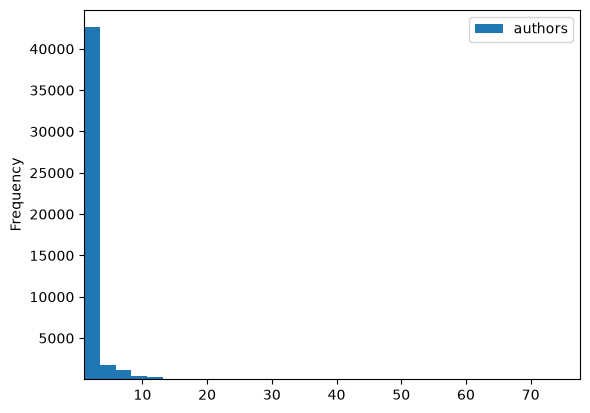

In [63]:
# Number of authors per conversation

query = '''SELECT conversation_id, count(distinct(author)) as authors
           FROM conversations
           GROUP BY conversation_id
           ORDER BY authors desc;'''

df = pd.read_sql(query, connection)
df.plot.hist(bins=30, ylim=(1), xlim=(1))

### Number of messages per conversation

<Axes: ylabel='Frequency'>

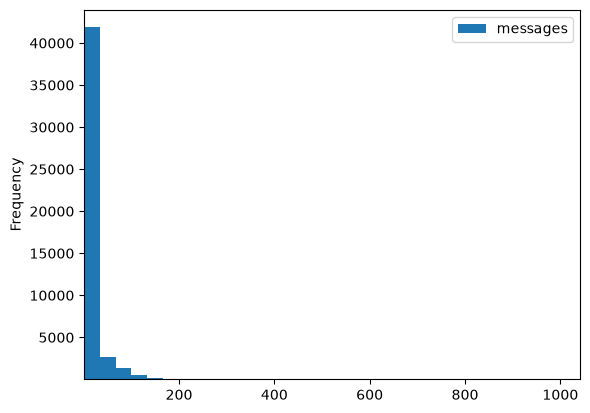

In [64]:
# Number of messages per conversation

query = '''SELECT conversation_id, count(distinct(message)) as messages
           FROM conversations
           GROUP BY conversation_id
           ORDER BY messages desc;'''

df = pd.read_sql(query, connection)
df.plot.hist(bins=30, ylim=(1), xlim=(1))

### WordCloud

#### WordCloud of all messages

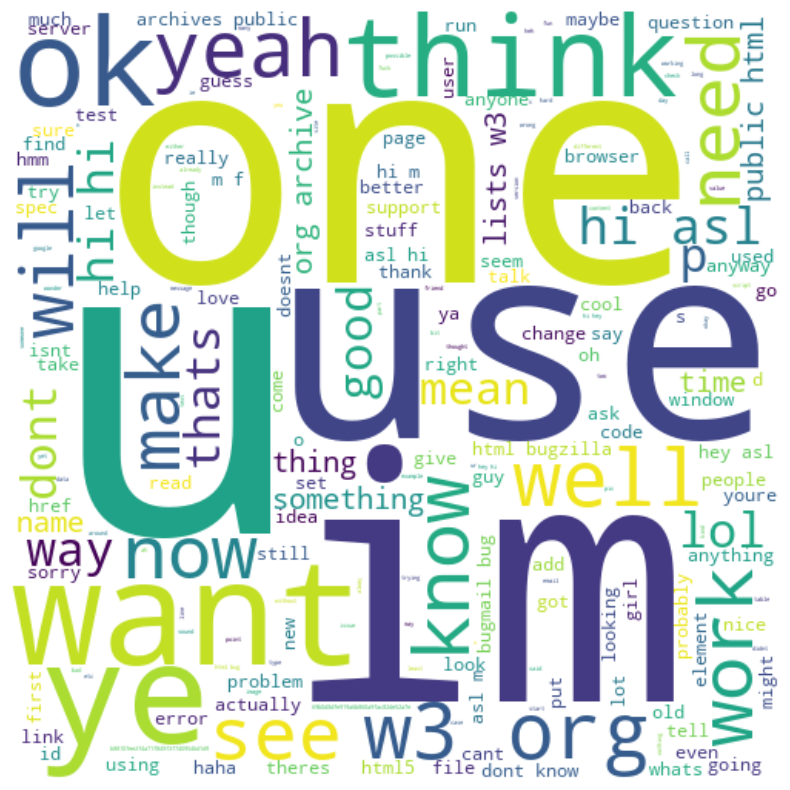

In [65]:
text = " ".join(message for message in dfBase['message'])

wordcloud = WordCloud(width=500, height=500, background_color="white").generate(text)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Saving image
wordcloud.to_file("wordcloud.png")

#### WordCloud of sexual predators messages

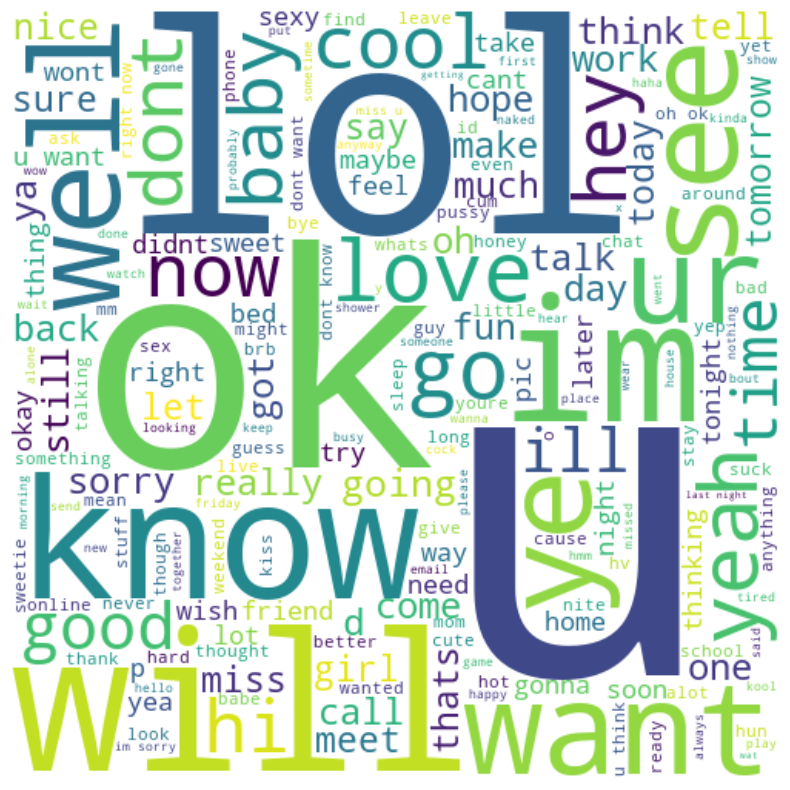

In [66]:
# Returns only messages from authors who are sexual predators
query = '''SELECT * FROM conversations WHERE author in (%s)''' % ','.join('?'*len(SEXUAL_PREDATORS))
aux = pd.read_sql(query, connection, params=SEXUAL_PREDATORS)

text = " ".join(message for message in aux['message'])

wordcloud = WordCloud(width=500, height=500, background_color="white").generate(text)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Saving image
wordcloud.to_file("wordcloud_predators.png")

### Save preprocessed dataset

In [67]:
# Dropping column "original_message"

dfBase.drop('original_message', inplace=True, axis=1)

#### Save predatory conversations dataset

In [68]:
dfPredatoryConversations = dfBase.copy()

# Returns only messages from authors who are sexual predators
query = '''SELECT * FROM conversations WHERE author in (%s)''' % ','.join('?'*len(SEXUAL_PREDATORS))
aux = pd.read_sql(query, connection, params=SEXUAL_PREDATORS)

predatoryConversations = aux['conversation_id'].unique()

# Adding column "predatory_conversation" with value False initially
# When the conversation is a predatory conversation, the label will be changed to True

dfPredatoryConversations = dfPredatoryConversations.assign(predatory_conversation = False)

for predatoryConversation in predatoryConversations:
  dfPredatoryConversations.loc[(dfPredatoryConversations['conversation_id'] ==  predatoryConversation), ['predatory_conversation']] = True

In [69]:
dfPredatoryConversations

,conversation_id,line,author,time,message,predatory_conversation
0,17784c5a093477c1706b1a68cea7c802,1,713349f3afa2dbe352d2abe4d3f01a12,03:10,hello,False
1,17784c5a093477c1706b1a68cea7c802,2,fcfda042c76436b97eca32b6c0490d1d,03:10,boys are shit,False
2,17784c5a093477c1706b1a68cea7c802,3,713349f3afa2dbe352d2abe4d3f01a12,03:10,that they are,False
3,17784c5a093477c1706b1a68cea7c802,4,fcfda042c76436b97eca32b6c0490d1d,03:10,hi,False
4,17784c5a093477c1706b1a68cea7c802,5,fcfda042c76436b97eca32b6c0490d1d,03:10,sorry,False
...,...,...,...,...,...,...
612341,0e3d6683515cdf8383587fa57d8780f7,3,b04c72cbf484c939a6ae0a872d8ffd9d,02:14,fuck you,False
612342,f4d4941aee777988cd1ab5bf654a0f07,1,ec478b5f04ae52f80267a9f521c30d91,12:35,hey,False
612343,f4d4941aee777988cd1ab5bf654a0f07,2,c4be3bef8bc54c090091ea09a0491458,12:35,hi,False
612344,f4d4941aee777988cd1ab5bf654a0f07,3,ec478b5f04ae52f80267a9f521c30d91,12:35,m or f,False


In [70]:
# Number of tuples for each value of the label 'predatory_conversation'

dfPredatoryConversations['predatory_conversation'].value_counts()

predatory_conversation
False    575514
True      36832
Name: count, dtype: int64

In [71]:
# Saving predatory conversations dataset

dfPredatoryConversations.to_csv(DRIVE_PATH + 'databases/test_predatoryconversations_preprocessed_full.csv', index=False, header=True, sep=';')

#### Save predators dataset

In [72]:
dfPredators = dfBase.copy()

# Adding column "predator" with value False initially
# When the author is a sexual predator, the label will be changed to True

dfPredators = dfPredators.assign(predator = False)

for predator in SEXUAL_PREDATORS:
  dfPredators.loc[(dfPredators['author'] ==  predator), ['predator']] = True

In [73]:
dfPredators

,conversation_id,line,author,time,message,predator
0,17784c5a093477c1706b1a68cea7c802,1,713349f3afa2dbe352d2abe4d3f01a12,03:10,hello,False
1,17784c5a093477c1706b1a68cea7c802,2,fcfda042c76436b97eca32b6c0490d1d,03:10,boys are shit,False
2,17784c5a093477c1706b1a68cea7c802,3,713349f3afa2dbe352d2abe4d3f01a12,03:10,that they are,False
3,17784c5a093477c1706b1a68cea7c802,4,fcfda042c76436b97eca32b6c0490d1d,03:10,hi,False
4,17784c5a093477c1706b1a68cea7c802,5,fcfda042c76436b97eca32b6c0490d1d,03:10,sorry,False
...,...,...,...,...,...,...
612341,0e3d6683515cdf8383587fa57d8780f7,3,b04c72cbf484c939a6ae0a872d8ffd9d,02:14,fuck you,False
612342,f4d4941aee777988cd1ab5bf654a0f07,1,ec478b5f04ae52f80267a9f521c30d91,12:35,hey,False
612343,f4d4941aee777988cd1ab5bf654a0f07,2,c4be3bef8bc54c090091ea09a0491458,12:35,hi,False
612344,f4d4941aee777988cd1ab5bf654a0f07,3,ec478b5f04ae52f80267a9f521c30d91,12:35,m or f,False


In [74]:
# Number of tuples for each value of the label 'predator'

dfPredators['predator'].value_counts()

predator
False    593029
True      19317
Name: count, dtype: int64

In [75]:
# Saving predators dataset

dfPredators.to_csv(DRIVE_PATH + 'databases/test_predators_preprocessed_full.csv', index=False, header=True, sep=';')